In [1]:
!pip install "numpy<2" roboticstoolbox-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.8 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 MB 8.9 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 64.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/1

In [5]:
import roboticstoolbox as rtb
import numpy as np
from spatialmath import SE3

# --- 1. SYSTEM VARIABLES AND CONSTANTS ---
H1 = 0.4 
L0 = 1.1 
L1 = 0.3 
L2 = 0.1 
H4 = 0.1 
L3 = 0.1 
L4 = 0.5 
A1 = 0.1  # Added: Lateral Offset parameter

# --- 2. DEFINE LINKS (Matches Table 1 in PDF) ---
links = [
    # Joint 1: Revolute (Theta1)
    # alpha=0, a=0, d=H1+L0, theta=q1
    rtb.RevoluteMDH(alpha=0, a=0, d=(H1 + L0), offset=0, qlim=[0, 2*np.pi]),

    # Joint 2: Prismatic (d2)
    # alpha=90, a=0, d=d2+L1, theta=0
    rtb.PrismaticMDH(alpha=np.pi/2, a=0, theta=0, offset=L1, qlim=[0.3, 1.5]),

    # Joint 3: Prismatic (d3)
    # alpha=90, a=A1, d=d3+(L2+H4+L3), theta=90 
    # UPDATED: Changed 'a=0' to 'a=A1' to account for the lateral offset
    rtb.PrismaticMDH(alpha=np.pi/2, a=A1, theta=np.pi/2, offset=(L2 + H4 + L3), qlim=[0.1, 0.15]),

    # Joint 4: Revolute (Theta4)
    # alpha=0, a=0, d=0, theta=q4
    rtb.RevoluteMDH(alpha=0, a=0, d=0, offset=0, qlim=[0, 2*np.pi])
]

# Create Robot
robot = rtb.DHRobot(links, name='4DOF_Bot')

# --- 3. DEFINE TOOL (Link 4->5) ---
# Translation of L4 along x
robot.tool = SE3.Tx(L4)

print("--- ROBOT DEFINITION ---")
print(robot)

# --- 4. CALCULATE MATRICES ---
# Test Config: q = [30 deg, 0.5, 0.12, 45 deg]
q_test = np.array([np.deg2rad(30), 0.5, 0.12, np.deg2rad(45)])

print(f"\n--- CALCULATED MATRICES for q = {np.round(q_test, 3)} ---")

# Matrix Calculation Loop
T_accumulated = SE3()

for i, link in enumerate(robot.links):
    matrix_Ai = link.A(q_test[i])
    print(f"\n[Matrix A{i+1}] (Link {i}->{i+1}):")
    # We round to 3 decimals for easy reading
    print(np.round(matrix_Ai.A, 3))
    T_accumulated = T_accumulated * matrix_Ai

# --- 5. VERIFICATION OF FINAL POSE ---
print("\n[Total T] (Base -> Tool Flange):")
print(np.round(T_accumulated.A, 3))

print("\n[Final End-Effector Pose] (Base -> Tip):")
final_pose = robot.fkine(q_test)
print(np.round(final_pose.A, 3))

# --- 6. AUTOMATIC CHECKER (Equation 7) ---
# Pz = (H1 + L0) - (d3 + L2 + H4 + L3)
Pz_toolbox = final_pose.A[2, 3]
# Using q_test[2] which is d3 (0.12)
Pz_manual = (H1 + L0) - (q_test[2] + L2 + H4 + L3)

print("\n--- CRITICAL CHECK ---")
print(f"Manual Pz Calculation: {Pz_manual:.3f}")
print(f"Toolbox Pz Output:     {Pz_toolbox:.3f}")

if abs(Pz_toolbox - Pz_manual) < 0.001:
    print(">>> VERIFICATION SUCCESSFUL: The toolbox matches.")
else:
    print(">>> VERIFICATION FAILED: Check offsets again.")

--- ROBOT DEFINITION ---
DHRobot: 4DOF_Bot, 4 joints (RPPR), dynamics, modified DH parameters
┌──────┬───────┬───────┬───────────────────────────┬──────┬────────┐
│ aⱼ₋₁ │ ⍺ⱼ₋₁  │  θⱼ   │            dⱼ             │  q⁻  │   q⁺   │
├──────┼───────┼───────┼───────────────────────────┼──────┼────────┤
│    0 │  0.0° │    q1 │                       1.5 │ 0.0° │ 360.0° │
│    0 │ 90.0° │  0.0° │                  q2 + 0.3 │  0.3 │    1.5 │
│  0.1 │ 90.0° │ 90.0° │  q3 + 0.30000000000000004 │  0.1 │   0.15 │
│    0 │  0.0° │    q4 │                         0 │ 0.0° │ 360.0° │
└──────┴───────┴───────┴───────────────────────────┴──────┴────────┘

┌──────┬─────────────────────────────────────┐
│ tool │ t = 0.5, 0, 0; rpy/xyz = 0°, 0°, 0° │
└──────┴─────────────────────────────────────┘


--- CALCULATED MATRICES for q = [0.524 0.5   0.12  0.785] ---

[Matrix A1] (Link 0->1):
[[ 0.866 -0.5    0.     0.   ]
 [ 0.5    0.866 -0.    -0.   ]
 [ 0.     0.     1.     1.5  ]
 [ 0.     0.     0.     1.   

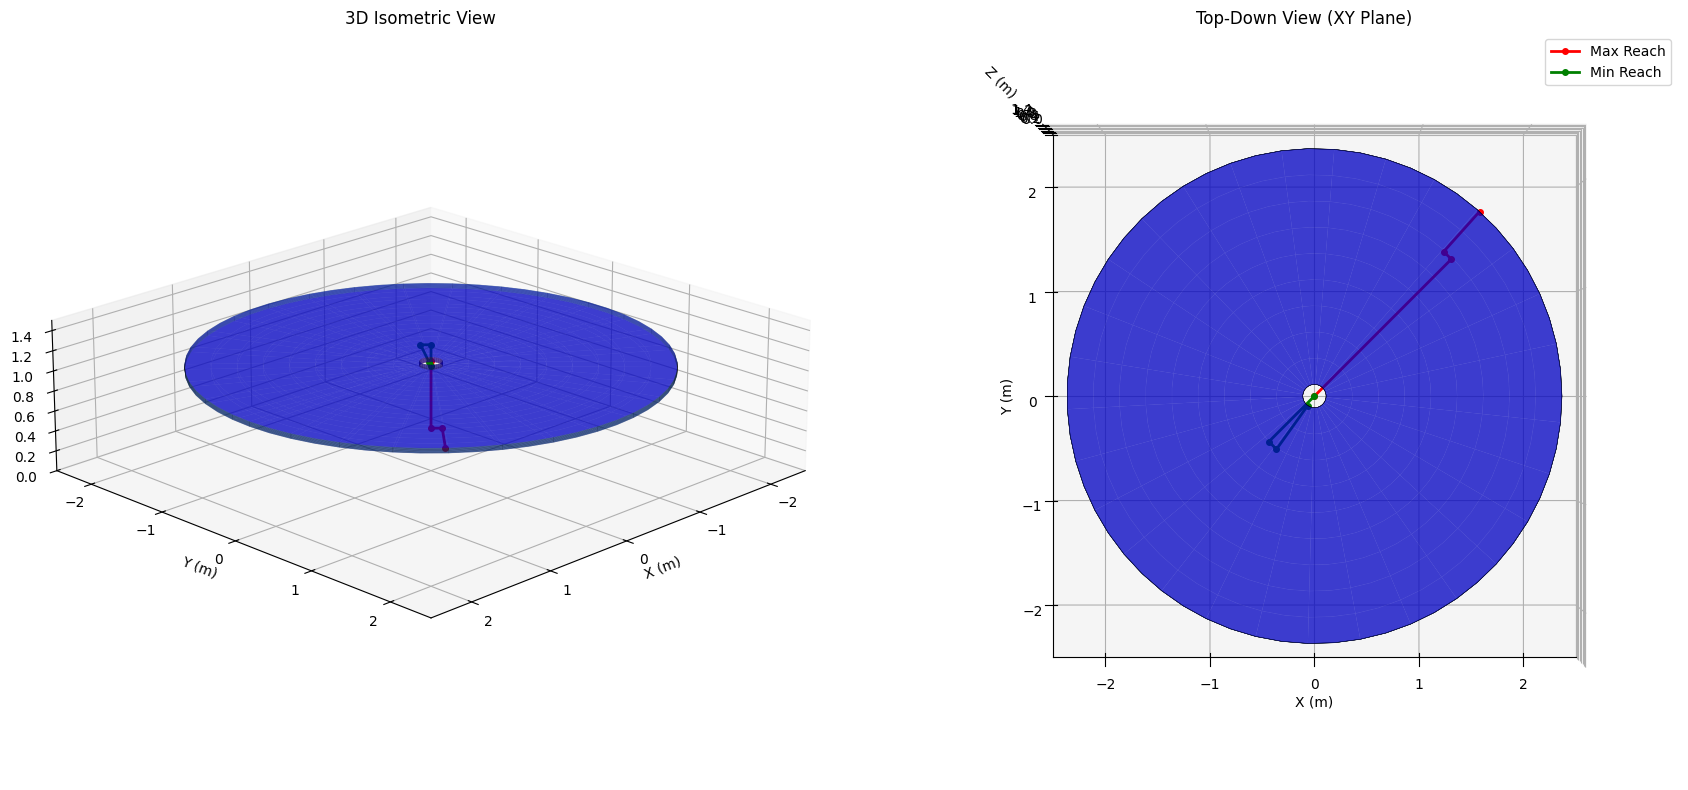

In [ ]:
# Code for Workspace plotting 
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# --- 1. SYSTEM PARAMETERS ---
H1, L0 = 0.4, 1.1
L1 = 0.3  # Reverted to 0.3
L2 = 0.1
H4, L3 = 0.1, 0.1
L4 = 0.5
A1 = 0.1  # Set to 0.1

d2_min, d2_max = 0.3, 1.5
d3_min, d3_max = 0.1, 0.15

# --- 2. CALCULATE BOUNDARIES ---
Z_max = (H1 + L0) - (d3_min + L2 + H4 + L3)
Z_min = (H1 + L0) - (d3_max + L2 + H4 + L3)

# Radial limits
Wrist_R_max = np.sqrt((d2_max + L1)**2 + A1**2)
Wrist_R_min = np.sqrt((d2_min + L1)**2 + A1**2)

R_max = Wrist_R_max + L4
R_min = np.abs(Wrist_R_min - L4)

# --- 3. GENERATE MESH DATA ---
theta = np.linspace(0, 2*np.pi, 60)
z = np.linspace(Z_min, Z_max, 10)
theta_grid, z_grid = np.meshgrid(theta, z)

x_outer = R_max * np.cos(theta_grid)
y_outer = R_max * np.sin(theta_grid)
x_inner = R_min * np.cos(theta_grid)
y_inner = R_min * np.sin(theta_grid)

# Caps
r = np.linspace(R_min, R_max, 10)
r_grid_cap, theta_grid_cap = np.meshgrid(r, theta)
x_cap = r_grid_cap * np.cos(theta_grid_cap)
y_cap = r_grid_cap * np.sin(theta_grid_cap)
z_top = np.full_like(x_cap, Z_max)
z_bot = np.full_like(x_cap, Z_min)

# --- 4. CALCULATE ROBOT SKELETONS ---

def get_skeleton(d2, z_height, rotation_angle, is_min=False):
    # 1. Construct the chain aligned with X-axis initially
    # P0: Base
    p0 = [0, 0, z_height] 
    # P1: End of Prismatic Extension (d2+L1) along X
    p1 = [d2 + L1, 0, z_height]
    # P2: End of Lateral Offset (A1) along Y (The Wrist)
    p2 = [d2 + L1, A1, z_height]
    
    # P3: Tool Tip
    # Calculate vector from Origin (0,0) to Wrist (P2)
    wrist_vec = np.array([p2[0], p2[1]]) 
    wrist_norm = np.linalg.norm(wrist_vec)
    wrist_dir = wrist_vec / wrist_norm # Normalize
    
    if is_min:
        # Fold back: Subtract L4 towards the origin
        p3_xy = wrist_vec - (wrist_dir * L4)
    else:
        # Extend out: Add L4 away from origin
        p3_xy = wrist_vec + (wrist_dir * L4)
        
    p3 = [p3_xy[0], p3_xy[1], z_height]
    
    # 2. Apply Rotation Matrix
    R_z = np.array([
        [np.cos(rotation_angle), -np.sin(rotation_angle), 0],
        [np.sin(rotation_angle),  np.cos(rotation_angle), 0],
        [0, 0, 1]
    ])
    
    pts = np.array([p0, p1, p2, p3])
    return pts @ R_z.T

# Define angles for opposite directions
angle_max = np.pi / 4          # 45 degrees
angle_min = angle_max + np.pi  # 225 degrees (Opposite)

skel_max = get_skeleton(d2_max, Z_max, angle_max, is_min=False)
skel_min = get_skeleton(d2_min, Z_min, angle_min, is_min=True)

# --- 5. PLOTTING ---
fig = plt.figure(figsize=(18, 8))
plot_configs = [
    {"pos": 121, "title": "3D Isometric View",       "elev": 20, "azim": 45},
    {"pos": 122, "title": "Top-Down View (XY Plane)", "elev": 90, "azim": -90}
]

for config in plot_configs:
    ax = fig.add_subplot(config["pos"], projection='3d')
    
    # Plot Volumes
    ax.plot_surface(x_outer, y_outer, z_grid, color='cyan', alpha=0.3, edgecolor='black', linewidth=0.2)
    ax.plot_surface(x_inner, y_inner, z_grid, color='red', alpha=0.3, edgecolor='black', linewidth=0.2)
    ax.plot_surface(x_cap, y_cap, z_top, color='blue', alpha=0.5)
    ax.plot_surface(x_cap, y_cap, z_bot, color='blue', alpha=0.5)

    # Plot Skeletons (Max = Red, Min = Green)
    # Using linewidth=2, markersize=4 as requested
    ax.plot(skel_max[:,0], skel_max[:,1], skel_max[:,2], 
            color='red', linewidth=2, marker='o', markersize=4, label='Max Reach')
    
    ax.plot(skel_min[:,0], skel_min[:,1], skel_min[:,2], 
            color='green', linewidth=2, marker='o', markersize=4, label='Min Reach')

    if config["pos"] == 122:
        ax.legend()

    ax.set_title(config["title"])
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_zlim(0.0, 1.5)
    ax.set_box_aspect((5, 5, 1.5))
    ax.view_init(elev=config["elev"], azim=config["azim"])

plt.tight_layout()
plt.show()

In [8]:
import numpy as np

# --- 1. SYSTEM PARAMETERS ---
H1, L0 = 0.4, 1.1
L1 = 0.3
L2 = 0.1
H4, L3 = 0.1, 0.1
L4 = 0.5
A1 = 0.1  # Lateral Offset

# --- 2. DEFINE ANALYTICAL FORWARD KINEMATICS ---
def forward_kinematics_pose(q):
    """
    Returns the Position (x, y, z) and global orientation angle (phi)
    phi is the angle of the tool relative to the base X-axis.
    """
    t1, d2, d3, t4 = q
    
    # Orientation of tool in base frame
    phi = t1 - t4
    
    # Position calculations including Lateral Offset A1
    px = L4 * np.sin(phi) + A1 * np.cos(t1) + (d2 + L1) * np.sin(t1)
    py = -L4 * np.cos(phi) + A1 * np.sin(t1) - (d2 + L1) * np.cos(t1)
    pz = (H1 + L0) - (d3 + L2 + H4 + L3)
    
    return np.array([px, py, pz, phi])

# --- 3. DEFINE ANALYTICAL JACOBIAN (FULL 6x4) ---
def jacobian_analytical(q):
    t1, d2, d3, t4 = q
    s1, c1 = np.sin(t1), np.cos(t1)
    # phi = t1 - t4
    s_phi, c_phi = np.sin(t1 - t4), np.cos(t1 - t4)
    
    # Initialize Full 6x4 Jacobian
    # Rows: [Vx, Vy, Vz, Wx, Wy, Wz]
    # Cols: [theta1, d2, d3, theta4]
    J = np.zeros((6, 4))
    
    # --- Linear Velocity Part (Rows 0-2) ---
    
    # Row 0: Vx
    # dx/dt1
    J[0, 0] = L4 * c_phi - A1 * s1 + (d2 + L1) * c1
    # dx/dd2
    J[0, 1] = s1
    # dx/dt4
    J[0, 3] = -L4 * c_phi
    
    # Row 1: Vy
    # dy/dt1
    J[1, 0] = L4 * s_phi + A1 * c1 + (d2 + L1) * s1
    # dy/dd2
    J[1, 1] = -c1
    # dy/dt4
    J[1, 3] = -L4 * s_phi 
    
    # Row 2: Vz
    # dz/dd3
    J[2, 2] = -1
    
    # --- Angular Velocity Part (Rows 3-5) ---
    # Based on axis identification:
    # Joint 1: Rotates around Z0 (+1 in Z)
    # Joint 2: Prismatic (0)
    # Joint 3: Prismatic (0)
    # Joint 4: Rotates around Z3 (which is -Z0, so -1 in Z)
    
    # Row 3: Wx
    # All zeros (Planar rotation only)
    
    # Row 4: Wy
    # All zeros (Planar rotation only)
    
    # Row 5: Wz
    J[5, 0] = 1   # theta1 contributes +1 to global rotation
    J[5, 3] = -1  # theta4 contributes -1 to global rotation
    
    return J

# --- 4. VERIFICATION (Numerical Check) ---
print("--- JACOBIAN CONSISTENCY CHECK ---")
q_test = np.array([np.deg2rad(30), 0.5, 0.12, np.deg2rad(10)])

# A. Analytical Result
J_ana = jacobian_analytical(q_test)
print("\n[Analytical Jacobian (6x4)]:")
print(np.round(J_ana, 3))

# B. Numerical Result (Finite Difference)
delta = 1e-6
J_num = np.zeros((6, 4))
pose_curr = forward_kinematics_pose(q_test) 
# pose_curr = [px, py, pz, phi]

for i in range(4):
    q_perturbed = q_test.copy()
    q_perturbed[i] += delta
    pose_new = forward_kinematics_pose(q_perturbed)
    
    # Calculate differences
    diff_pose = (pose_new - pose_curr) / delta
    
    # Fill Numerical Jacobian
    # 1. Linear Velocity (Rows 0-2) -> derived from x, y, z changes
    J_num[0:3, i] = diff_pose[0:3]
    
    # 2. Angular Velocity (Rows 3-5) -> derived from phi changes
    # Since rotation is only around Z-axis for this robot:
    J_num[3, i] = 0  # Wx
    J_num[4, i] = 0  # Wy
    J_num[5, i] = diff_pose[3] # Wz = d(phi)/dt

print("\n[Numerical Jacobian (Finite Diff)]:")
print(np.round(J_num, 3))

# C. Compare
diff = np.linalg.norm(J_ana - J_num)
if diff < 1e-4:
    print(f"\n>>> SUCCESS: Analytical Jacobian matches Numerical derivation.")
else:
    print(f"\n>>> FAILURE: Mismatch found (Error: {diff:.6f}). Check Derivatives.")

--- JACOBIAN CONSISTENCY CHECK ---

[Analytical Jacobian (6x4)]:
[[ 1.113  0.5    0.    -0.47 ]
 [ 0.658 -0.866  0.    -0.171]
 [ 0.     0.    -1.     0.   ]
 [ 0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.   ]
 [ 1.     0.     0.    -1.   ]]

[Numerical Jacobian (Finite Diff)]:
[[ 1.113  0.5    0.    -0.47 ]
 [ 0.658 -0.866  0.    -0.171]
 [ 0.     0.    -1.     0.   ]
 [ 0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.   ]
 [ 1.     0.     0.    -1.   ]]

>>> SUCCESS: Analytical Jacobian matches Numerical derivation.


In [9]:
import numpy as np

# --- 1. SETUP ROBOT ---
H1, L0 = 0.4, 1.1
L1 = 0.3
L2 = 0.1
H4, L3 = 0.1, 0.1
L4 = 0.5
A1 = 0.1  # Added Lateral Offset

# --- 2. DEFINE ANALYTICAL IK FUNCTION ---
def inverse_kinematics_analytical(T_target):
    # Extract Target
    px, py, pz = T_target[0, 3], T_target[1, 3], T_target[2, 3]
    
    # Extract Orientation from Rotation Matrix
    r11 = T_target[0, 0]
    r21 = T_target[1, 0]
    
    theta_14 = np.arctan2(r11, -r21)
    
    # --- STEP 1: Vertical ---
    d3 = (H1 + L0) - (L2 + H4 + L3) - pz
    
    # --- STEP 2: Wrist Position ---
    # Decouple wrist from tool length
    x_wrist = px - L4 * np.sin(theta_14)
    y_wrist = py + L4 * np.cos(theta_14)
    
    # --- STEP 3 & 4: Base Angle and Extension ---
    # Calculate geometry accounting for offset A1
    R_sq = x_wrist**2 + y_wrist**2
    term_sqrt = np.sqrt(R_sq - A1**2)
    
    # Extension
    d2 = term_sqrt - L1
    
    # Base Angle
    beta = np.arctan2(x_wrist, -y_wrist)
    delta = np.arctan2(A1, term_sqrt)
    theta1 = beta - delta
    
    # --- STEP 5: Tool Rotation ---
    theta4 = theta1 - theta_14
    
    return np.array([theta1, d2, d3, theta4])

# --- 3. VERIFICATION LOOP ---
print("--- TESTING ANALYTICAL IK ---")

q_original = np.array([np.deg2rad(30), 0.8, 0.12, np.deg2rad(10)])
print(f"1. Original Q: {np.round(q_original, 3)}")

# B. Calculate FK Matrix T manually
t1, d2, d3, t4 = q_original
phi = t1 - t4
s_phi, c_phi = np.sin(phi), np.cos(phi)
s1, c1 = np.sin(t1), np.cos(t1)

T_target = np.eye(4)
# Rotation
T_target[0,0] = s_phi;  T_target[0,1] = c_phi
T_target[1,0] = -c_phi; T_target[1,1] = s_phi
T_target[2,2] = -1

# Position (Updated to include A1)
T_target[0,3] = L4*s_phi + A1*c1 + (d2 + L1)*s1
T_target[1,3] = -L4*c_phi + A1*s1 - (d2 + L1)*c1
T_target[2,3] = (H1 + L0) - (d3 + L2 + H4 + L3)

print("\n2. Target Pose T:")
print(np.round(T_target, 3))

# C. Solve IK
q_calc = inverse_kinematics_analytical(T_target)
print(f"\n3. Computed Q: {np.round(q_calc, 3)}")

# D. Check
err = np.linalg.norm(q_original - q_calc)
if err < 1e-5:
    print("\n>>> SUCCESS: IK matches FK perfectly.")
else:
    print(f"\n>>> FAILURE: Error {err:.6f}")

--- TESTING ANALYTICAL IK ---
1. Original Q: [0.524 0.8   0.12  0.175]

2. Target Pose T:
[[ 0.342  0.94   0.     0.808]
 [-0.94   0.342  0.    -1.372]
 [ 0.     0.    -1.     1.08 ]
 [ 0.     0.     0.     1.   ]]

3. Computed Q: [0.524 0.8   0.12  0.175]

>>> SUCCESS: IK matches FK perfectly.


In [10]:
import numpy as np
import roboticstoolbox as rtb
from spatialmath import SE3

# --- 1. SETUP ROBOT ---
H1, L0 = 0.4, 1.1
L1 = 0.3
L2 = 0.1
H4, L3 = 0.1, 0.1
L4 = 0.5
A1 = 0.1  # Added Lateral Offset

links = [
    # Joint 1: Base Rotation
    rtb.RevoluteMDH(alpha=0, a=0, d=(H1 + L0), offset=0),
    
    # Joint 2: Prismatic Extension (alpha=90)
    rtb.PrismaticMDH(alpha=np.pi/2, a=0, theta=0, offset=L1, qlim=[0.3, 1.5]),
    
    # Joint 3: Prismatic Vertical
    rtb.PrismaticMDH(alpha=np.pi/2, a=A1, theta=np.pi/2, offset=(L2 + H4 + L3), qlim=[0.1, 0.15]),
    
    # Joint 4: Wrist Rotation
    rtb.RevoluteMDH(alpha=0, a=0, d=0, offset=0)
]
robot = rtb.DHRobot(links, name='4DOF_Verifier')
robot.tool = SE3.Tx(L4)

# --- 2. DEFINE YOUR ANALYTICAL FORMULA ---
def ik_analytical(T):
    # Extract Position
    px, py, pz = T.t[0], T.t[1], T.t[2]
    
    # Extract Orientation
    r11 = T.R[0, 0]
    r21 = T.R[1, 0]
    
    theta_14 = np.arctan2(r11, -r21)
    
    # 1. Vertical (d3)
    d3 = (H1 + L0) - (L2 + H4 + L3) - pz
    
    # 2. Wrist Position
    # Decouple wrist from tool length
    x_wrist = px - L4 * np.sin(theta_14)
    y_wrist = py + L4 * np.cos(theta_14)
    
    # 3. Planar Position (theta1, d2)
    R_sq = x_wrist**2 + y_wrist**2
    term_sqrt = np.sqrt(R_sq - A1**2)
    
    # Extension
    d2 = term_sqrt - L1
    
    # Base Angle
    beta = np.arctan2(x_wrist, -y_wrist)
    delta = np.arctan2(A1, term_sqrt)
    theta1 = beta - delta
    
    # 4. Tool Rotation (theta4)
    theta4 = theta1 - theta_14
    
    return np.array([theta1, d2, d3, theta4])

# --- 3. THE COMPARISON TEST ---
print("--- CROSS-VERIFICATION: ANALYTICAL VS TOOLBOX NUMERICAL ---")

# A. Generate a random valid target
q_target = np.array([np.deg2rad(45), 0.6, 0.13, np.deg2rad(15)])
T_target = robot.fkine(q_target)

print(f"Target Configuration: {np.round(q_target, 3)}")
print(f"Target Position (XYZ): {np.round(T_target.t, 3)}")

# B. Solve using YOUR FORMULA
q_analytical = ik_analytical(T_target)
print(f"\n[1] Your Analytical Solution:   {np.round(q_analytical, 3)}")

# C. Solve using TOOLBOX NUMERICAL SOLVER
# Mask [1,1,1,0,0,1] matches X, Y, Z and Yaw (Rotation about Z)
sol = robot.ikine_LM(T_target, q0=q_target, mask=[1, 1, 1, 0, 0, 1])

if sol.success:
    q_toolbox = sol.q
    print(f"[2] Toolbox Numerical Solution: {np.round(q_toolbox, 3)}")
    
    # D. Check Agreement
    diff = np.linalg.norm(q_analytical - q_toolbox)
    print(f"\nDifference (Norm): {diff:.6f}")

    if diff < 1e-4:
        print(">>> MATCH CONFIRMED: Derivation matches the numerical solver.")
    else:
        print(">>> MISMATCH: The analytical logic differs from the numerical solver.")
else:
    print(">>> TOOLBOX SOLVER FAILED (Numerical issue, not a formula error).")

--- CROSS-VERIFICATION: ANALYTICAL VS TOOLBOX NUMERICAL ---
Target Configuration: [0.785 0.6   0.13  0.262]
Target Position (XYZ): [ 0.957 -0.999  1.07 ]

[1] Your Analytical Solution:   [0.785 0.6   0.13  0.262]
[2] Toolbox Numerical Solution: [0.785 0.6   0.13  0.262]

Difference (Norm): 0.000000
>>> MATCH CONFIRMED: Derivation matches the numerical solver.
